# Perfecting the comb on the toy — the shared-line theorem and the recovery design

The activation-spectrum treatment (notebook 06) left the production comb (d = 40,
hw = 0.18) with exactly two imperfections on the toy ladder:

1. **contaminated-true loss** — the P5-outer level 0.230 sits below any threshold
   that rejects the grass, so the trues inside contaminated clusters are dropped;
2. **the hub-centre residual 0.434** — the one false level the comb fails to crush.

This notebook shows these are *the same spectral object* and perfects the design
against it, in five steps:

- **§1 The line atlas.** Every canonical cluster's uniform-$b$-excited eigenvalue
  lines, exactly. The key fact: the contaminated-P5 odd lines and the hub-$K_{1,3}$
  lines **coincide exactly** at $s\pm\sqrt3$.
- **§2 The trade-off theorem.** Over *all* spectral filters, the surviving hub
  population is $\ge \tfrac32\times$ the recovered contaminated-true level — with the
  exact menu of strategies (symmetric / centre-null / leg-null).
- **§3 The designs.** The (d, hw) comb family is one-dimensional (hub ≈ 1.9 × P5-outer
  everywhere); escaping it needs explicit recovery passes. Three perfected designs are
  calibrated on the ladder.
- **§4 The census.** What the toy actually contains vs T and ε: contamination is the
  dominant efficiency loss; hubs and floor bridges are rare.
- **§5 Measured validation.** Fresh statevector solves on store events (3 reps,
  T = 100…1000, plus the ε = 4 mrad stress point): spectra, per-type levels,
  separation functionals, and segment metrics under the three threshold conventions.

Throughout: γ = 3, δ = 1, s = γ+δ = 4, clean noise (σ_scatt = 10⁻⁴, σ_res = 0),
ε = 2 mrad unless stated, signal-support rescale against the classical partner.

In [1]:
import sys, json, time
for p in ("/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/_shared",
          "/data/bfys/gscriven/LHCb_VeLo_Toy_Model/src"):
    if p not in sys.path: sys.path.insert(0,p)
from pathlib import Path
import numpy as np, pandas as pd, scipy.sparse as sp
import numpy.polynomial.chebyshev as cheb
from scipy.sparse.csgraph import connected_components
from scipy.sparse.linalg import eigsh, minres
import matplotlib.pyplot as plt
import qtrk_pipeline as qp
from lhcb_velo_toy.solvers.quantum import QSVT, design_line_comb_inverse, design_minimax_comb
plt.rcParams.update({"figure.dpi":115,"font.size":11,"axes.grid":True,"grid.alpha":0.3})
OUT=Path("/data/bfys/gscriven/Quantum_Track_Reconstruction/QSVT/Segment_level_studies/outputs/perfect_toy")
OUT.mkdir(parents=True,exist_ok=True)
CACHE=OUT/"cache"; CACHE.mkdir(exist_ok=True)
S=4.0; TAU=qp.threshold_for(3.0,1.0); T1=np.pi/S
P4=S-2*np.cos(np.arange(1,5)*np.pi/5)          # 2.382, 3.382, 4.618, 5.618
R3m,R3p=S-np.sqrt(3),S+np.sqrt(3)              # 2.268, 5.732 — the shared lines
DOM=(S-3.8,S+3.8)
def chain(m):
    M=S*np.eye(m)
    for i in range(m-1): M[i,i+1]=M[i+1,i]=-1
    return M
def star(m):
    M=S*np.eye(m+1)
    for j in range(1,m+1): M[0,j]=M[j,0]=-1
    return M
def tbranch():   # true P4 chain (nodes 0-3) + false leaf (node 4) sharing node 1
    M=S*np.eye(5)
    for i,j in ((0,1),(1,2),(2,3),(1,4)): M[i,j]=M[j,i]=-1
    return M
def excited(M):
    w,U=np.linalg.eigh(M); beta=U.T@np.ones(len(M))
    k=np.abs(beta)>1e-9
    return w[k],beta[k],U[:,k]
def levels(M,f):
    w,U=np.linalg.eigh(M); beta=U.T@np.ones(len(M))
    return U@(beta*f(w))
POPS={"P4 outer":(chain(4),0),"P4 inner":(chain(4),1),
      "P5 outer":(chain(5),0),"P5 mid":(chain(5),1),"P5 ctr":(chain(5),2),
      "hub ctr":(star(3),0),"hub leg":(star(3),1),
      "P3 outer":(chain(3),0),"P3 ctr":(chain(3),1),
      "P2":(chain(2),0),"isolated":(np.array([[S]]),0)}
def ladder(f):
    anc=abs(levels(chain(4),f)[1])
    return {k: float(abs(levels(M,f)[i])*0.4545/anc) for k,(M,i) in POPS.items()}
def savefig(fig,name):
    for e,dp in (("pdf",600),("png",300)):
        fig.savefig(OUT/f"{name}.{e}",dpi=dp,bbox_inches="tight",facecolor="white")
EV={}
def event_arrays(T,rep,eps):
    """(A csr, truth) for a store event — memoized for the session."""
    k=(T,rep,round(eps,6))
    if k not in EV:
        ev,_=qp.ensure_event(n_trk=T,rep=rep,sigma_scatt=1e-4,sigma_res=0.0,phi_max=0.2,hit_ineff=0.0)
        ham=qp.build_hamiltonian(ev,epsilon=eps,gamma=3.0,delta=1.0)
        EV[k]=(ham.A.tocsr(),np.asarray(qp.truth_from_event(ev),bool))
    return EV[k]
def truth_of(T,rep):
    f=CACHE/f"truth_T{T}_r{rep}.npz"
    if f.exists(): return np.load(f)["t"]
    ev,_=qp.ensure_event(n_trk=T,rep=rep,sigma_scatt=1e-4,sigma_res=0.0,phi_max=0.2,hit_ineff=0.0)
    t=np.asarray(qp.truth_from_event(ev),bool)
    np.savez_compressed(f,t=t)
    return t
print("setup ok | tau =",TAU,"| P4 lines",np.round(P4,4),"| shared lines",round(R3m,4),round(R3p,4))

setup ok | tau = 0.35 | P4 lines [2.382 3.382 4.618 5.618] | shared lines 2.2679 5.7321


## 1. The line atlas — where every population lives in $\lambda$

For the chain $P_m$ the spectrum is $\lambda_k = s - 2\cos\frac{k\pi}{m+1}$ with
eigenvectors $u_k(i) \propto \sin\frac{ik\pi}{m+1}$; the uniform source $b=\mathbf 1$
couples only to **odd $k$** (parity selection: $\beta_k = \sum_i u_k(i) = 0$ for even
$k$). For the star $K_{1,m}$ the excited lines are $s \pm \sqrt m$ (the $(m{-}1)$-fold
degenerate level at $s$ is dark: centre weight 0, legs sum to 0).

**The coincidence.** The contaminated-P5 cluster (a true P4 plus one false extension)
has odd lines
$$\{s - 2\cos\tfrac{\pi}{6},\; s - 2\cos\tfrac{3\pi}{6},\; s - 2\cos\tfrac{5\pi}{6}\}
= \{s-\sqrt3,\; s,\; s+\sqrt3\},$$
**identical** to the full excited line set of the hub $K_{1,3}$. Since every
spectral filter is a single function $f(\lambda)$, whatever $f$ does to recover the
contaminated trues at $s\pm\sqrt3$ it also does to the hub falses — they are
distinguishable only through the *per-line coefficients* $c_k(i)=\beta_k u_k(i)$,
never through line position. Two further exact facts follow from symmetry:

- **The mirror tax.** The chain reflection $i \mapsto 6-i$ commutes with $P_5$, so
  $x_5 = x_1$ for *any* filter: each recovered contaminated cluster brings its false
  extension along at **exactly** the recovered-true level. One false per ~4 trues,
  irreducible.
- **The sharp limit loses contamination.** Contaminated clusters have zero excited
  weight on the P4 lines (the census below measures 2/304 lines near P4 at T = 1000),
  so an infinitely sharp P4 comb nulls *all* contaminated trues — maximal rejection
  and maximal contamination loss are the same limit.

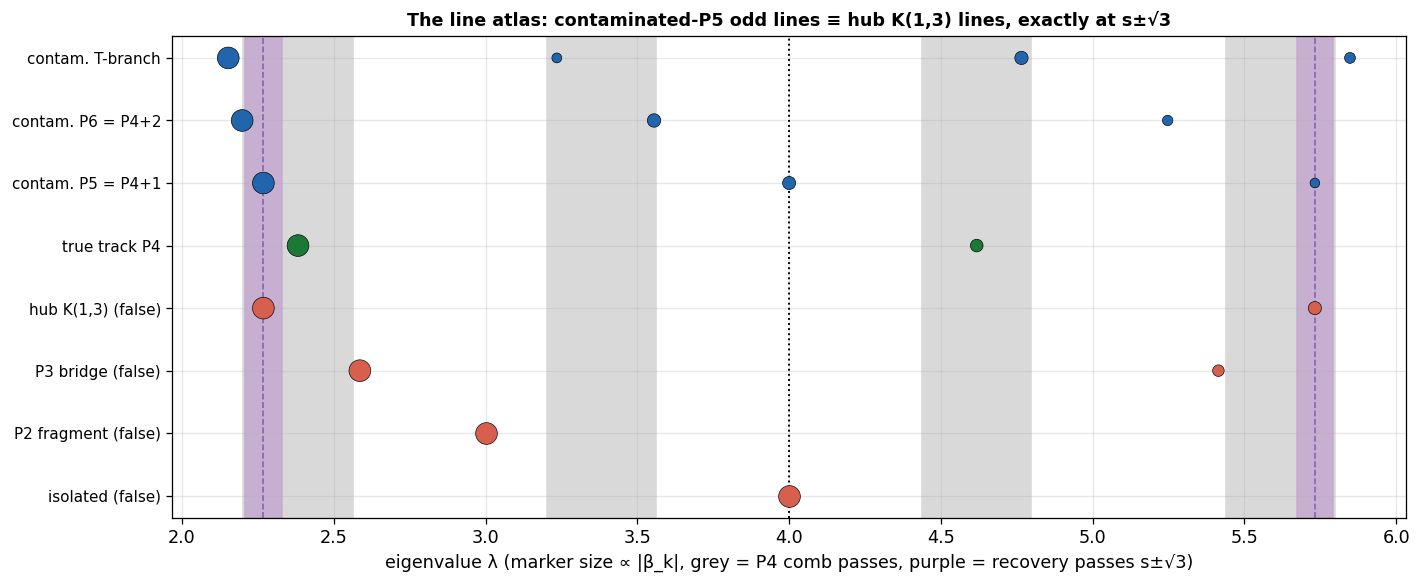

per-line coefficients c_k = β_k u_k(i) on the shared lines (x = c₋·f₋ + c₊·f₊):
                 c(s−√3)  c(s+√3)
P5 outer (true)   0.6220   0.0447
P5 mid (true)     1.0774  -0.0774
P5 ctr (true)     1.2440   0.0893
hub ctr (false)   1.3660  -0.3660
hub leg (false)   0.7887   0.2113


In [2]:
ATLAS=[("isolated (false)",np.array([[S]]),"#d6604d"),
       ("P2 fragment (false)",chain(2),"#d6604d"),
       ("P3 bridge (false)",chain(3),"#d6604d"),
       ("hub K(1,3) (false)",star(3),"#d6604d"),
       ("true track P4",chain(4),"#1b7837"),
       ("contam. P5 = P4+1",chain(5),"#2166ac"),
       ("contam. P6 = P4+2",chain(6),"#2166ac"),
       ("contam. T-branch",tbranch(),"#2166ac")]
fig,ax=plt.subplots(figsize=(12.5,5.2))
lam=np.linspace(DOM[0],DOM[1],2000)
for m_,hwband in zip(P4,[0.18]*4):
    ax.axvspan(m_-0.18,m_+0.18,color="0.85",zorder=0)
for r in (R3m,R3p):
    ax.axvspan(r-0.06,r+0.06,color="#c2a5cf",alpha=0.8,zorder=0)
for row,(name,M,c) in enumerate(ATLAS):
    w,b,U=excited(M)
    ax.scatter(w,np.full_like(w,row),s=160*np.abs(b)/np.abs(b).max()+25,
               color=c,zorder=3,edgecolor="k",linewidth=0.4)
ax.axvline(S,color="k",ls=":",lw=1.2)
for r in (R3m,R3p): ax.axvline(r,color="#6a3d9a",ls="--",lw=1.0,alpha=0.7)
ax.set_yticks(range(len(ATLAS))); ax.set_yticklabels([a[0] for a in ATLAS],fontsize=9.5)
ax.set_xlabel("eigenvalue λ (marker size ∝ |β_k|, grey = P4 comb passes, purple = recovery passes s±√3)")
ax.set_title("The line atlas: contaminated-P5 odd lines ≡ hub K(1,3) lines, exactly at s±√3",
             fontweight="bold",fontsize=11)
fig.tight_layout(); savefig(fig,"01_line_atlas"); plt.show()
# the per-line coefficient table on the shared lines (f(s)=0 enforced by the iso notch)
w5,b5,U5=excited(chain(5)); wh,bh,Uh=excited(star(3))
i5m,i5p=np.argmin(np.abs(w5-R3m)),np.argmin(np.abs(w5-R3p))
TABLE=pd.DataFrame({
  "c(s−√3)":[ (b5*U5[0])[i5m],(b5*U5[1])[i5m],(b5*U5[2])[i5m],(bh*Uh[0])[0],(bh*Uh[1])[0]],
  "c(s+√3)":[ (b5*U5[0])[i5p],(b5*U5[1])[i5p],(b5*U5[2])[i5p],(bh*Uh[0])[1],(bh*Uh[1])[1]]},
  index=["P5 outer (true)","P5 mid (true)","P5 ctr (true)","hub ctr (false)","hub leg (false)"])
print("per-line coefficients c_k = β_k u_k(i) on the shared lines (x = c₋·f₋ + c₊·f₊):")
print(TABLE.round(4).to_string())

## 2. The trade-off theorem

With the isolated notch mandatory ($f(s)=0$), a spectral filter has exactly **two
degrees of freedom** on the shared lines: $f_\mp = f(s\mp\sqrt3)$. Every population
above is linear in $(f_-,f_+)$, so the whole design space is a *direction* in this
plane (scale cancels in the anchor normalisation). Scanning all directions:

$$\min_{f}\;\frac{\max(|x_{\rm hub\,ctr}|,\,|x_{\rm hub\,leg}|)}{|x_{\rm P5\,outer}|}
= \frac{3}{2}\,,\qquad\text{attained at } f_+=f_-.$$

The exact menu (ratios of surviving-hub level to recovered-true level, from the
coefficient table):

| strategy | $f_+/f_-$ | hub ctr | hub leg | active falses per hub |
|---|---|---|---|---|
| symmetric (optimal ratio) | $1$ | $\tfrac32\times$ | $\tfrac32\times$ | **4** |
| centre-null | $2+\sqrt3$ | $0$ | $2\times$ | **3** |
| **leg-null** | $-(2+\sqrt3)$ | $6\times$ | $0$ | **1** |

No direction puts *both* hub populations below the recovered trues (the two
feasibility cones are disjoint), so **some hub population always survives above the
recovered contaminated-true level**. The count-weighted optimum is therefore
**leg-null**: concentrate the unavoidable hub survival in the single centre segment
(1 false per hub) rather than the three legs. The production comb, with symmetric
Gaussian tails weighted by $1/\lambda$, sits near the symmetric direction but at
amplitude too small to recover ($0.230 < \tau$) — it pays the hub-centre residual
**without** collecting the recovery gain. That is the imperfection this notebook removes.

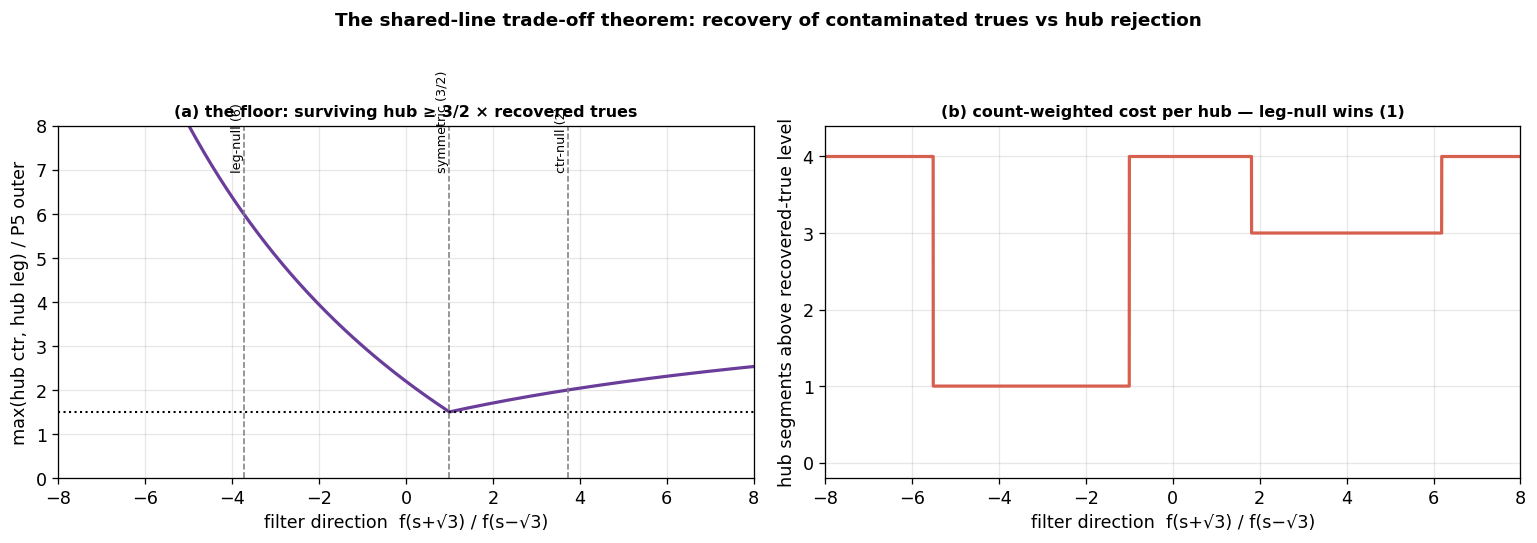

min over all filters of max(hub)/P5outer = 1.5000 at f+/f- = 1.0000


In [3]:
th=np.linspace(1e-4,np.pi-1e-4,200001)
fm,fp=np.cos(th),np.sin(th)
c5o=(b5*U5[0]); chc=(bh*Uh[0]); chl=(bh*Uh[1])
P5o=np.abs(c5o[i5m]*fm+c5o[i5p]*fp)
HC=np.abs(chc[0]*fm+chc[1]*fp); HL=np.abs(chl[0]*fm+chl[1]*fp)
ratio=np.maximum(HC,HL)/np.maximum(P5o,1e-300)
cost=1.0*(HC>=P5o-1e-12)+3.0*(HL>=P5o-1e-12)
fig,ax=plt.subplots(1,2,figsize=(13.5,4.6))
x=fp/fm  # f+/f- (signed)
o=np.argsort(x)
ax[0].plot(x[o],ratio[o],lw=2,color="#6a3d9a")
ax[0].axhline(1.5,color="k",ls=":",lw=1.3); ax[0].set_ylim(0,8); ax[0].set_xlim(-8,8)
for v,lab in ((1.0,"symmetric (3/2)"),(2+np.sqrt(3),"ctr-null (2)"),(-(2+np.sqrt(3)),"leg-null (6)")):
    ax[0].axvline(v,color="0.5",ls="--",lw=1); ax[0].annotate(lab,(v,7.0),rotation=90,fontsize=8,ha="right")
ax[0].set_xlabel("filter direction  f(s+√3) / f(s−√3)")
ax[0].set_ylabel("max(hub ctr, hub leg) / P5 outer")
ax[0].set_title("(a) the floor: surviving hub ≥ 3/2 × recovered trues",fontweight="bold",fontsize=10)
ax[1].plot(x[o],cost[o],lw=2,color="#d6604d")
ax[1].set_xlim(-8,8); ax[1].set_ylim(-0.2,4.4)
ax[1].set_xlabel("filter direction  f(s+√3) / f(s−√3)")
ax[1].set_ylabel("hub segments above recovered-true level")
ax[1].set_title("(b) count-weighted cost per hub — leg-null wins (1)",fontweight="bold",fontsize=10)
fig.suptitle("The shared-line trade-off theorem: recovery of contaminated trues vs hub rejection",
             fontsize=11.5,fontweight="bold",y=1.02)
fig.tight_layout(); savefig(fig,"02_tradeoff_theorem"); plt.show()
i=np.argmin(ratio)
print(f"min over all filters of max(hub)/P5outer = {ratio[i]:.4f} at f+/f- = {fp[i]/fm[i]:.4f}")

## 3. The designs — the comb family is one-dimensional; the recovery comb escapes it

First the fact that motivates explicit recovery passes: across the **entire**
$(d,\mathrm{hw})$ plane of the least-squares comb, hub-centre $\approx 1.9\times$
P5-outer (the $1/\lambda$-weighted symmetric-tail prediction is
$\tfrac{1.366/2.268-0.366/5.732}{0.622/2.268+0.045/5.732} = 1.91$). Degree and
half-width move the family *along* this line (both ends die together in the sharp
limit) but never off it. The minimax (LP) comb is worse everywhere on the ladder —
its equiripple spreads error into the hub/P5 lines — settling the D4 question:
**the d = 10 minimax comb is not a production design.**

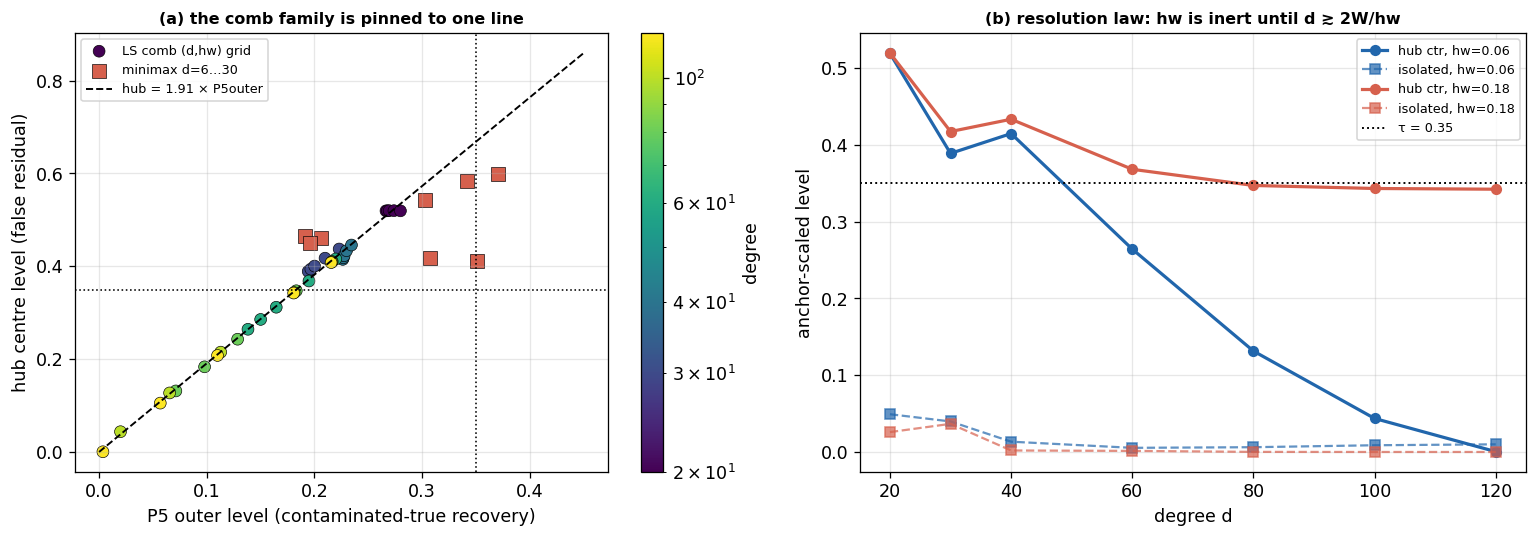

In [4]:
scan_f=CACHE/"design_scan.csv"
if scan_f.exists():
    SC=pd.read_csv(scan_f)
else:
    rows=[]
    for d in (20,30,40,60,80,100,120):
        for hw in (0.06,0.09,0.12,0.18,0.24):
            L=ladder(design_line_comb_inverse(degree=d,hw=hw))
            rows.append(dict(family="LS comb",d=d,hw=hw,**L))
    for d in (6,8,10,12,16,20,24,30):
        L=ladder(design_minimax_comb(degree=d))
        rows.append(dict(family="minimax",d=d,hw=0.18,**L))
    SC=pd.DataFrame(rows); SC.to_csv(scan_f,index=False)
fig,ax=plt.subplots(1,2,figsize=(13.5,4.8))
ls=SC[SC.family=="LS comb"]; mm=SC[SC.family=="minimax"]
sc=ax[0].scatter(ls["P5 outer"],ls["hub ctr"],c=ls["d"],s=55,cmap="viridis",
                 norm=plt.matplotlib.colors.LogNorm(),edgecolor="k",linewidth=0.4,label="LS comb (d,hw) grid")
ax[0].scatter(mm["P5 outer"],mm["hub ctr"],c="#d6604d",s=70,marker="s",
              edgecolor="k",linewidth=0.4,label="minimax d=6…30")
xx=np.linspace(0,0.45,10); ax[0].plot(xx,1.91*xx,"k--",lw=1.2,label="hub = 1.91 × P5outer")
ax[0].axhline(TAU,color="k",ls=":",lw=1); ax[0].axvline(TAU,color="k",ls=":",lw=1)
plt.colorbar(sc,ax=ax[0],label="degree")
ax[0].set_xlabel("P5 outer level (contaminated-true recovery)")
ax[0].set_ylabel("hub centre level (false residual)")
ax[0].set_title("(a) the comb family is pinned to one line",fontweight="bold",fontsize=10)
ax[0].legend(fontsize=8,loc="upper left")
for hw,c in ((0.06,"#2166ac"),(0.18,"#d6604d")):
    dd=ls[ls.hw==hw].sort_values("d")
    ax[1].plot(dd["d"],dd["hub ctr"],"o-",color=c,lw=2,label=f"hub ctr, hw={hw}")
    ax[1].plot(dd["d"],dd["isolated"],"s--",color=c,lw=1.4,alpha=0.7,label=f"isolated, hw={hw}")
ax[1].axhline(TAU,color="k",ls=":",lw=1.2,label="τ = 0.35")
ax[1].set_xlabel("degree d"); ax[1].set_ylabel("anchor-scaled level")
ax[1].set_title("(b) resolution law: hw is inert until d ≳ 2W/hw",fontweight="bold",fontsize=10)
ax[1].legend(fontsize=8)
fig.tight_layout(); savefig(fig,"03_comb_family_1d"); plt.show()

### The three perfected designs

- **production** — `design_line_comb_inverse(d=40, hw=0.18)`: the store baseline.
- **sharp** — `d=120, hw=0.06`: maximal rejection; entire false ladder ≤ 0.02, the
  contaminated trues sacrificed. The clean-cluster purist.
- **recovery** — P4 comb (hw = 0.07) **plus explicit leg-null passes** at $s\pm\sqrt3$,
  half-width 0.06, weights Newton-calibrated on the *realized* ladder so hub-leg = 0
  and P5-outer = P4-outer = 0.3636 exactly. The accepted price: hub-centre at 6× and a
  ×0.11 LCU success-probability factor (the |p| ≤ 1 renormalisation).
- **recovery-wide** (hwr = 0.12) is included to show the window is **boxed in**: the
  P6 line at $s-2\cos\frac\pi7 = 2.198$ sits 0.07 below the pass centre, the P4-outer
  line 0.114 above it — widening the pass immediately distorts the true levels.

recovery calibrated: gm=0.8594 gp=-3.2633 (f+/f-=-3.797 vs −(2+√3)=−3.732), renorm |p|max=2.83 → success ×0.113
recovery-wide:       gm=4.4176 gp=-16.5706, |p|max=16.52

realized activation ladders (anchor-scaled, τ = 0.35):
          comb d40 (prod)  sharp d120  recovery d120  recovery-wide  classical    1BQF
P4 inner           0.4545      0.4545         0.4545         0.4545     0.4545  0.4545
P4 outer           0.3652      0.3613         0.3657         0.2949     0.3636  0.2242
P5 outer           0.2297      0.0036         0.3636         0.3635     0.3653  0.2243
P5 mid             0.3749      0.0004         1.0964         1.0897     0.4615  0.4485
P5 ctr             0.4614      0.0028         0.7328         0.7263     0.4807  0.4485
hub ctr            0.4336      0.0005         2.1928         2.1793     0.5384  0.6728
hub leg            0.3163      0.0003         0.0000         0.0002     0.3846  0.2243
P3 outer           0.1786      0.0154         0.0038         0.0012     0.3571 

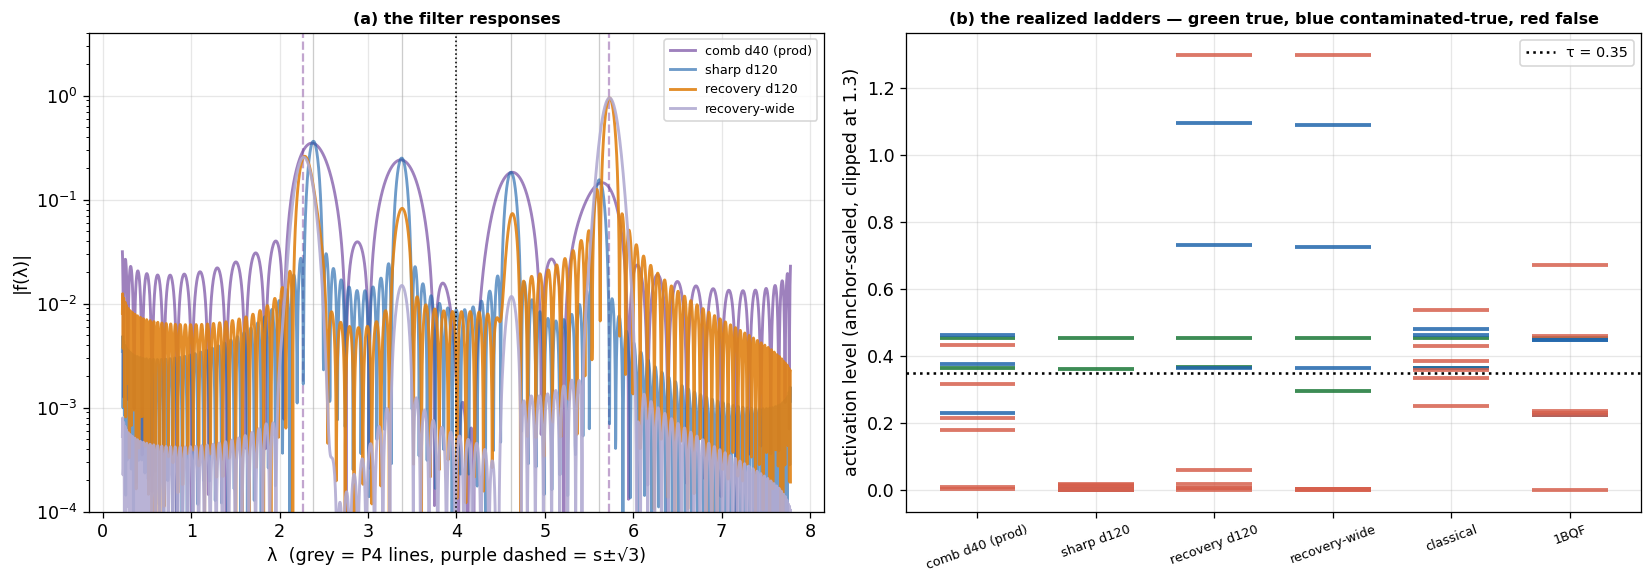

In [5]:
def build_recovery(gm,gp,deg=120,hw=0.07,hwr=0.06,ngrid=12000):
    x=np.linspace(DOM[0],DOM[1],ngrid); y=np.zeros_like(x)
    for m_ in P4: y=np.maximum(y,np.exp(-((x-m_)/hw)**2))
    y=y/np.clip(x,P4[0],None)
    y=y+gm*np.exp(-((x-R3m)/hwr)**2)+gp*np.exp(-((x-R3p)/hwr)**2)
    p=cheb.Chebyshev.fit(x,y,deg,domain=list(DOM))
    mx=float(np.max(np.abs(p(x))))
    return (p/(mx/0.95) if mx>1 else p),mx
def calibrate(hw=0.07,hwr=0.06,deg=120,target=0.3636):
    gm,gp=0.86,-3.26
    for it in range(8):
        p,_=build_recovery(gm,gp,deg,hw,hwr)
        anc=abs(levels(chain(4),p)[1])
        F=np.array([levels(star(3),p)[1]/anc*0.4545,
                    levels(chain(5),p)[0]/anc*0.4545-target])
        if max(abs(F))<2e-4: break
        J=np.zeros((2,2)); e=0.02
        for j,(dm,dp_) in enumerate(((e,0),(0,e))):
            p2,_=build_recovery(gm+dm,gp+dp_,deg,hw,hwr)
            a2=abs(levels(chain(4),p2)[1])
            F2=np.array([levels(star(3),p2)[1]/a2*0.4545,
                         levels(chain(5),p2)[0]/a2*0.4545-target])
            J[:,j]=(F2-F)/e
        st=np.linalg.solve(J,-F); gm+=st[0]; gp+=st[1]
    p,mx=build_recovery(gm,gp,deg,hw,hwr)
    return p,(gm,gp),mx
P_PROD=design_line_comb_inverse(degree=40,hw=0.18)
P_SHARP=design_line_comb_inverse(degree=120,hw=0.06)
P_REC,(gm,gp),mx_rec=calibrate()
P_RECW,(gmw,gpw),mx_recw=calibrate(hwr=0.12)
DESIGNS={"comb d40 (prod)":P_PROD,"sharp d120":P_SHARP,
         "recovery d120":P_REC,"recovery-wide":P_RECW}
DCOL={"comb d40 (prod)":"#6a3d9a","sharp d120":"#2166ac",
      "recovery d120":"#e08214","recovery-wide":"#b2abd2","classical":"#1b7837","1BQF":"#d6604d"}
print(f"recovery calibrated: gm={gm:.4f} gp={gp:.4f} (f+/f-={gp/gm:.3f} vs −(2+√3)=−3.732), "
      f"renorm |p|max={mx_rec:.2f} → success ×{(0.95/mx_rec)**2:.3f}")
print(f"recovery-wide:       gm={gmw:.4f} gp={gpw:.4f}, |p|max={mx_recw:.2f}")
LADDERS=pd.DataFrame({k:ladder(p) for k,p in DESIGNS.items()})
LADDERS["classical"]=pd.Series(ladder(lambda l:1.0/l))
LADDERS["1BQF"]=pd.Series(ladder(lambda l:np.cos(l*T1/2)))
order=["P4 inner","P4 outer","P5 outer","P5 mid","P5 ctr","hub ctr","hub leg",
       "P3 outer","P3 ctr","P2","isolated"]
LADDERS=LADDERS.loc[order]
print("\nrealized activation ladders (anchor-scaled, τ = 0.35):")
print(LADDERS.round(4).to_string())
fig,ax=plt.subplots(1,2,figsize=(14.5,5.2))
lam=np.linspace(DOM[0]+0.02,DOM[1]-0.02,3000)
for k,p in DESIGNS.items():
    ax[0].plot(lam,np.abs(p(lam)),lw=1.8,color=DCOL[k],label=k,
               alpha=0.9 if "recovery" in k else 0.65)
for m_ in P4: ax[0].axvline(m_,color="0.8",lw=0.8,zorder=0)
for r in (R3m,R3p): ax[0].axvline(r,color="#c2a5cf",lw=1.4,ls="--",zorder=0)
ax[0].axvline(S,color="k",ls=":",lw=1)
ax[0].set_yscale("log"); ax[0].set_ylim(1e-4,4)
ax[0].set_xlabel("λ  (grey = P4 lines, purple dashed = s±√3)"); ax[0].set_ylabel("|f(λ)|")
ax[0].set_title("(a) the filter responses",fontweight="bold",fontsize=10)
ax[0].legend(fontsize=8)
true_pops={"P4 inner","P4 outer"}; contam_pops={"P5 outer","P5 mid","P5 ctr"}
xpos={n:i for i,n in enumerate(LADDERS.columns)}
for pop in LADDERS.index:
    c="#1b7837" if pop in true_pops else ("#2166ac" if pop in contam_pops else "#d6604d")
    for n in LADDERS.columns:
        v=min(LADDERS.loc[pop,n],1.3)
        ax[1].hlines(v,xpos[n]-0.32,xpos[n]+0.32,color=c,lw=2.4,alpha=0.85)
ax[1].axhline(TAU,color="k",ls=":",lw=1.6,label=f"τ = {TAU}")
ax[1].set_xticks(list(xpos.values())); ax[1].set_xticklabels(LADDERS.columns,fontsize=8,rotation=20)
ax[1].set_ylabel("activation level (anchor-scaled, clipped at 1.3)")
ax[1].set_title("(b) the realized ladders — green true, blue contaminated-true, red false",
                fontweight="bold",fontsize=10)
ax[1].legend(fontsize=9)
fig.tight_layout(); savefig(fig,"04_designs_and_ladders"); plt.show()

## 4. The census — what the toy actually contains

The theorem prices recovery in *hub units*; whether to pay depends on how many hubs
and contaminated clusters an event actually has. Census over the store events
(3 reps): cluster taxonomy of every connected component, plus the excited lines of
every contaminated cluster (≤ 10 segments) against the recovery passes.

In [6]:
LABNAMES=["clean true","contam true","contam false","isolated","P2","P3",
          "floor bridge","hub ctr","hub leg","other false"]
def census(T,rep,eps):
    f=CACHE/f"census_T{T}_r{rep}_e{int(eps*1e4)}.npz"
    if f.exists():
        z=np.load(f); return z["lab"],z["lines"],int(z["nclus"])
    A,truth=event_arrays(T,rep,eps)
    n=A.shape[0]
    Cm=(S*sp.identity(n,format='csr')-A); Cm.setdiag(0); Cm.eliminate_zeros()
    Cm=(abs(Cm)>1e-9).astype(np.int8)
    deg=np.asarray(Cm.sum(1)).ravel()
    ncl,labc=connected_components(Cm,directed=False)
    seglab=np.full(n,9,np.int8); lines=[]; ncontam=0
    sizes=np.bincount(labc); order_=np.argsort(labc)
    bounds=np.cumsum(np.concatenate([[0],sizes]))
    for c in range(ncl):
        mem=order_[bounds[c]:bounds[c+1]]; m=len(mem); nt=int(truth[mem].sum())
        if nt==m: seglab[mem]=0; continue
        if nt>0:
            ncontam+=1
            seglab[mem]=np.where(truth[mem],1,2)
            if m<=10:
                w,U=np.linalg.eigh(A[mem][:,mem].toarray())
                be=U.T@np.ones(m); lines+=list(w[np.abs(be)>1e-6])
            continue
        if m==1: seglab[mem]=3
        elif m==2: seglab[mem]=4
        elif m==3: seglab[mem]=5
        elif m==4:
            dd=np.sort(deg[mem])
            if (dd==[1,1,2,2]).all():
                w=np.linalg.eigvalsh(A[mem][:,mem].toarray())
                seglab[mem]=6 if np.max(np.abs(np.sort(w)-P4))<0.05 else 9
            elif (dd==[1,1,1,3]).all():
                seglab[mem]=np.where(deg[mem]==3,7,8)
            else: seglab[mem]=9
        else: seglab[mem]=9
    lines=np.array(lines) if lines else np.zeros(0)
    np.savez_compressed(f,lab=seglab,lines=lines,nclus=ncontam)
    return seglab,lines,ncontam
TS=[100,200,400,700,1000]
rows=[]; LINES={}
for T in TS:
    for rep in (0,1,2):
        lab,ln,nc=census(T,rep,0.002)
        cnt=np.bincount(lab,minlength=10)
        rows.append(dict(T=T,eps=0.002,rep=rep,nclus=nc,
                         **{LABNAMES[i]:int(cnt[i]) for i in range(10)}))
        LINES.setdefault((T,0.002),[]).append(ln)
for eps in (0.004,0.006):
    for rep in (0,1,2):
        lab,ln,nc=census(400,rep,eps)
        cnt=np.bincount(lab,minlength=10)
        rows.append(dict(T=400,eps=eps,rep=rep,nclus=nc,
                         **{LABNAMES[i]:int(cnt[i]) for i in range(10)}))
        LINES.setdefault((400,eps),[]).append(ln)
CEN=pd.DataFrame(rows)
G=CEN.groupby(["eps","T"]).mean(numeric_only=True).drop(columns="rep")
print("census means over reps:")
print(G.round(1).to_string())

census means over reps:
            nclus  clean true  contam true  contam false   isolated       P2      P3  floor bridge  hub ctr  hub leg  other false
eps   T                                                                                                                          
0.002 100     0.7       397.3          2.7           0.7    39577.3     22.0     0.0           0.0      0.0      0.0          0.0
      200     0.3       797.3          2.7           2.7   159052.0    145.3     0.0           0.0      0.0      0.0          0.0
      400    11.7      1549.3         50.7          20.0   637152.0   1212.7    14.0           0.0      0.3      1.0          0.0
      700    36.7      2645.3        154.7          52.3  1951009.3   5931.3   203.0           0.0      1.0      3.0          0.0
      1000   73.3      3682.7        317.3         118.3  3976873.7  18044.7   923.0          13.3      6.0     18.0          3.0
0.004 400    46.3      1400.0        200.0          80.0   633543.

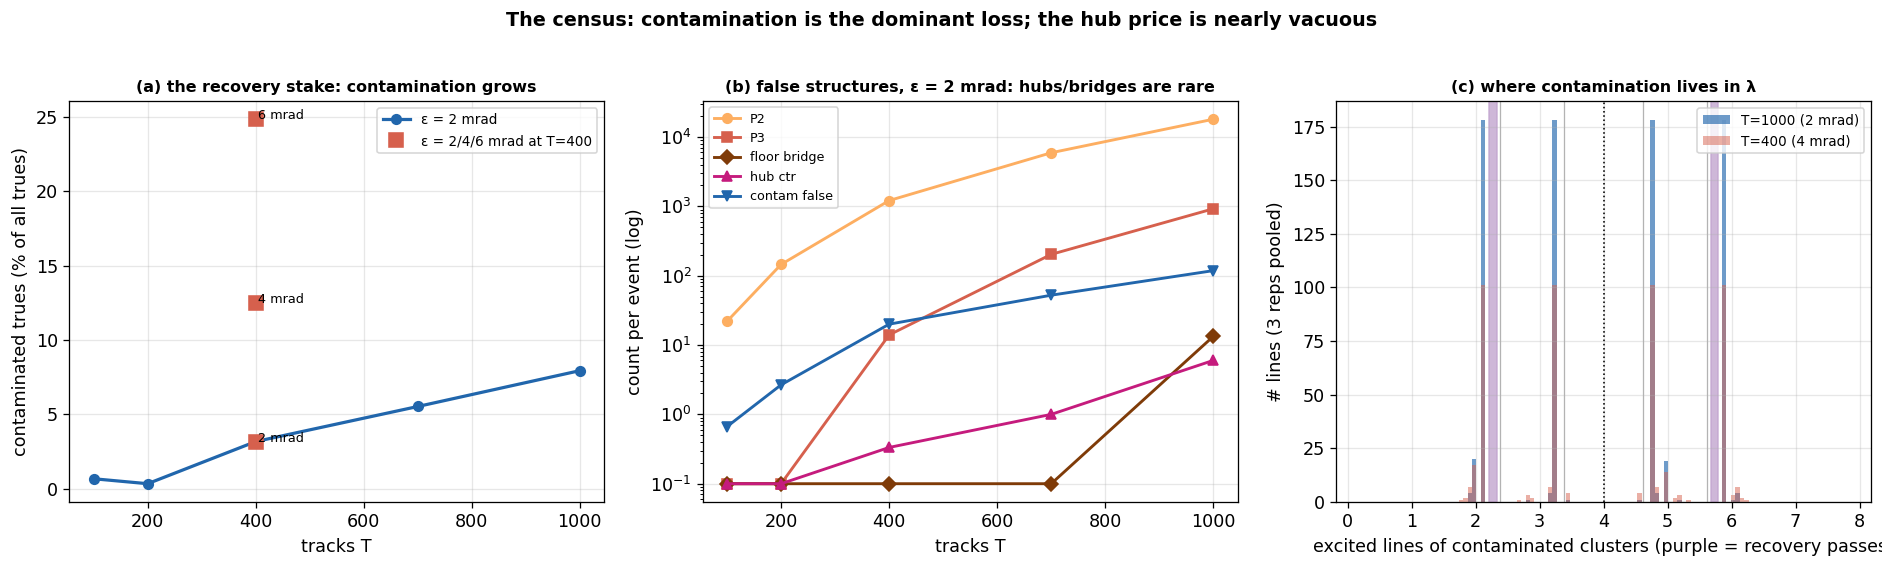

T=1000 contaminated lines: 772 | inside recovery passes 356 (46%) | near P4 lines 2 (0.3%)


In [7]:
fig,ax=plt.subplots(1,3,figsize=(16.5,4.8))
g2=CEN[CEN.eps==0.002].groupby("T").mean(numeric_only=True)
ax[0].plot(g2.index,100*g2["contam true"]/(g2["contam true"]+g2["clean true"]),
           "o-",color="#2166ac",lw=2,label="ε = 2 mrad")
ge=CEN[CEN["T"]==400].groupby("eps").mean(numeric_only=True)
ax[0].plot([400]*len(ge),100*ge["contam true"]/(ge["contam true"]+ge["clean true"]),
           "s",color="#d6604d",ms=9,label="ε = 2/4/6 mrad at T=400")
for e_,r_ in ge.iterrows():
    ax[0].annotate(f"{e_*1e3:.0f} mrad",(405,100*r_['contam true']/(r_['contam true']+r_['clean true'])),fontsize=8)
ax[0].set_xlabel("tracks T"); ax[0].set_ylabel("contaminated trues (% of all trues)")
ax[0].set_title("(a) the recovery stake: contamination grows",fontweight="bold",fontsize=10)
ax[0].legend(fontsize=8.5)
for k,c,mk in (("P2","#fdae61","o"),("P3","#d6604d","s"),("floor bridge","#7f3b08","D"),
               ("hub ctr","#c51b7d","^"),("contam false","#2166ac","v")):
    ax[1].plot(g2.index,np.maximum(g2[k],0.1),mk+"-",color=c,lw=1.8,ms=6,label=k)
ax[1].set_yscale("log"); ax[1].set_xlabel("tracks T"); ax[1].set_ylabel("count per event (log)")
ax[1].set_title("(b) false structures, ε = 2 mrad: hubs/bridges are rare",fontweight="bold",fontsize=10)
ax[1].legend(fontsize=8)
ln400=np.concatenate(LINES[(400,0.002)]); ln1000=np.concatenate(LINES[(1000,0.002)])
bins=np.linspace(DOM[0],DOM[1],110)
ax[2].hist(ln1000,bins=bins,color="#2166ac",alpha=0.65,label="T=1000 (2 mrad)")
ax[2].hist(np.concatenate(LINES[(400,0.004)]),bins=bins,color="#d6604d",alpha=0.5,label="T=400 (4 mrad)")
for m_ in P4: ax[2].axvline(m_,color="0.7",lw=0.8)
for r in (R3m,R3p): ax[2].axvspan(r-0.06,r+0.06,color="#c2a5cf",alpha=0.8)
ax[2].axvline(S,color="k",ls=":",lw=1)
ax[2].set_xlabel("excited lines of contaminated clusters (purple = recovery passes)")
ax[2].set_ylabel("# lines (3 reps pooled)")
ax[2].set_title("(c) where contamination lives in λ",fontweight="bold",fontsize=10)
ax[2].legend(fontsize=8.5)
fig.suptitle("The census: contamination is the dominant loss; the hub price is nearly vacuous",
             fontsize=12,fontweight="bold",y=1.02)
fig.tight_layout(); savefig(fig,"05_census"); plt.show()
nr=np.abs(ln1000[:,None]-np.array([R3m,R3p])[None,:]).min(1)<0.12
np4=np.min(np.abs(ln1000[:,None]-P4[None,:]),axis=1)<0.12
print(f"T=1000 contaminated lines: {len(ln1000)} | inside recovery passes {nr.sum()} "
      f"({100*nr.mean():.0f}%) | near P4 lines {np4.sum()} ({100*np4.mean():.1f}%)")

## 5. Measured validation — fresh solves on the store events

Production comb / classical / 1BQF come from the store (`sol_key` npz); the sharp and
recovery designs are solved fresh through the package `QSVT` class (matrix-free
Chebyshev statevector, spectral bounds from one Lanczos on $C = sI - A$) on the *same
store events*, cached locally. All non-classical solutions are mapped to ladder units
by the signal-support rescale against their classical partner.

In [8]:
sols=pd.read_csv(qp.manifest_dir()/"solutions.csv")
FX=sols[(sols.eps_provenance=="set")&(sols.epsilon.round(6)==0.002)&(sols.gamma==3.0)&
        (sols.hit_ineff==0.0)&np.isclose(sols.sigma_scatt,1e-4)&np.isclose(sols.sigma_res,0.0)]
FX=FX.drop_duplicates(subset="sol_key")
CD=sols[(sols.study=="QSVT_codesign")&(sols.epsilon.round(6)==0.004)]
if "fork_beta" in CD.columns:
    CD=CD[(CD.fork_beta.fillna(0.0)==0.0)]
CD=CD.drop_duplicates(subset="sol_key")
def store_sol(T,rep,solver,eps=0.002):
    src=FX if eps==0.002 else CD
    r=src[(src.n_trk==T)&(src.rep==rep)&(src.solver==solver)]
    if not len(r) or not qp.solution_exists(r.iloc[0].sol_key): return None
    return np.abs(np.asarray(qp.load_solution(r.iloc[0].sol_key)["sol"],float))
def rho_of(T,rep,eps):
    f=CACHE/f"rho_T{T}_r{rep}_e{int(eps*1e4)}.npz"
    if f.exists(): return float(np.load(f)["rho"])
    A,_=event_arrays(T,rep,eps)
    Cmat=S*sp.identity(A.shape[0],format='csr')-A
    rho=float(eigsh(Cmat,k=1,which='LA',return_eigenvectors=False,tol=1e-3,maxiter=5000)[0])
    np.savez_compressed(f,rho=rho)
    return rho
def fresh(T,rep,eps,design):
    f=CACHE/f"sol_T{T}_r{rep}_e{int(eps*1e4)}_{design.replace(' ','_')}.npz"
    if f.exists():
        z=np.load(f); return z["sol"],float(z["succ"])
    rho=rho_of(T,rep,eps)
    assert S+rho*1.03+0.05<DOM[1], f"spectrum too wide for fixed domain: rho={rho:.2f}"
    A,_=event_arrays(T,rep,eps)
    qv=QSVT(A,np.ones(A.shape[0]),poly=DESIGNS[design],spectral_bounds=(S-rho-0.02,S+rho+0.02))
    sol,succ=qv.solve_statevector()
    sol=np.asarray(sol,float)
    np.savez_compressed(f,sol=sol,succ=succ)
    return sol,succ
def get(T,rep,design,eps=0.002):
    """(amplitudes in ladder units, truth) or None"""
    solC=store_sol(T,rep,"classical",eps)
    if solC is None:
        f=CACHE/f"solC_T{T}_r{rep}_e{int(eps*1e4)}.npz"
        if f.exists(): solC=np.load(f)["sol"]
        else:
            A,_=event_arrays(T,rep,eps)
            solC=np.abs(np.asarray(minres(A.tocsc(),np.ones(A.shape[0]),rtol=1e-9,maxiter=8000)[0]))
            np.savez_compressed(f,sol=solC)
    truth=truth_of(T,rep)
    if design=="classical": return solC,truth
    if design=="1BQF":
        s=store_sol(T,rep,"quantum",eps)
        if s is None: return None
        return np.abs(qp.rescale_to_signal(s,solC,TAU)),truth
    if design=="comb d40 (prod)" and eps in (0.002,0.004):
        s=store_sol(T,rep,"qsvt",eps)
        if s is not None: return np.abs(qp.rescale_to_signal(s,solC,TAU)),truth
    s,_=fresh(T,rep,eps,design if design in DESIGNS else "comb d40 (prod)")
    return np.abs(qp.rescale_to_signal(s,solC,TAU)),truth
t0=time.time()
for T in TS:
    for rep in (0,1,2):
        for dsg in ("sharp d120","recovery d120","recovery-wide"):
            fresh(T,rep,0.002,dsg)
for rep in (0,1,2):
    for dsg in ("sharp d120","recovery d120","recovery-wide"):
        fresh(400,rep,0.004,dsg)
print(f"all fresh solves done/cached in {time.time()-t0:.0f}s")

all fresh solves done/cached in 1s


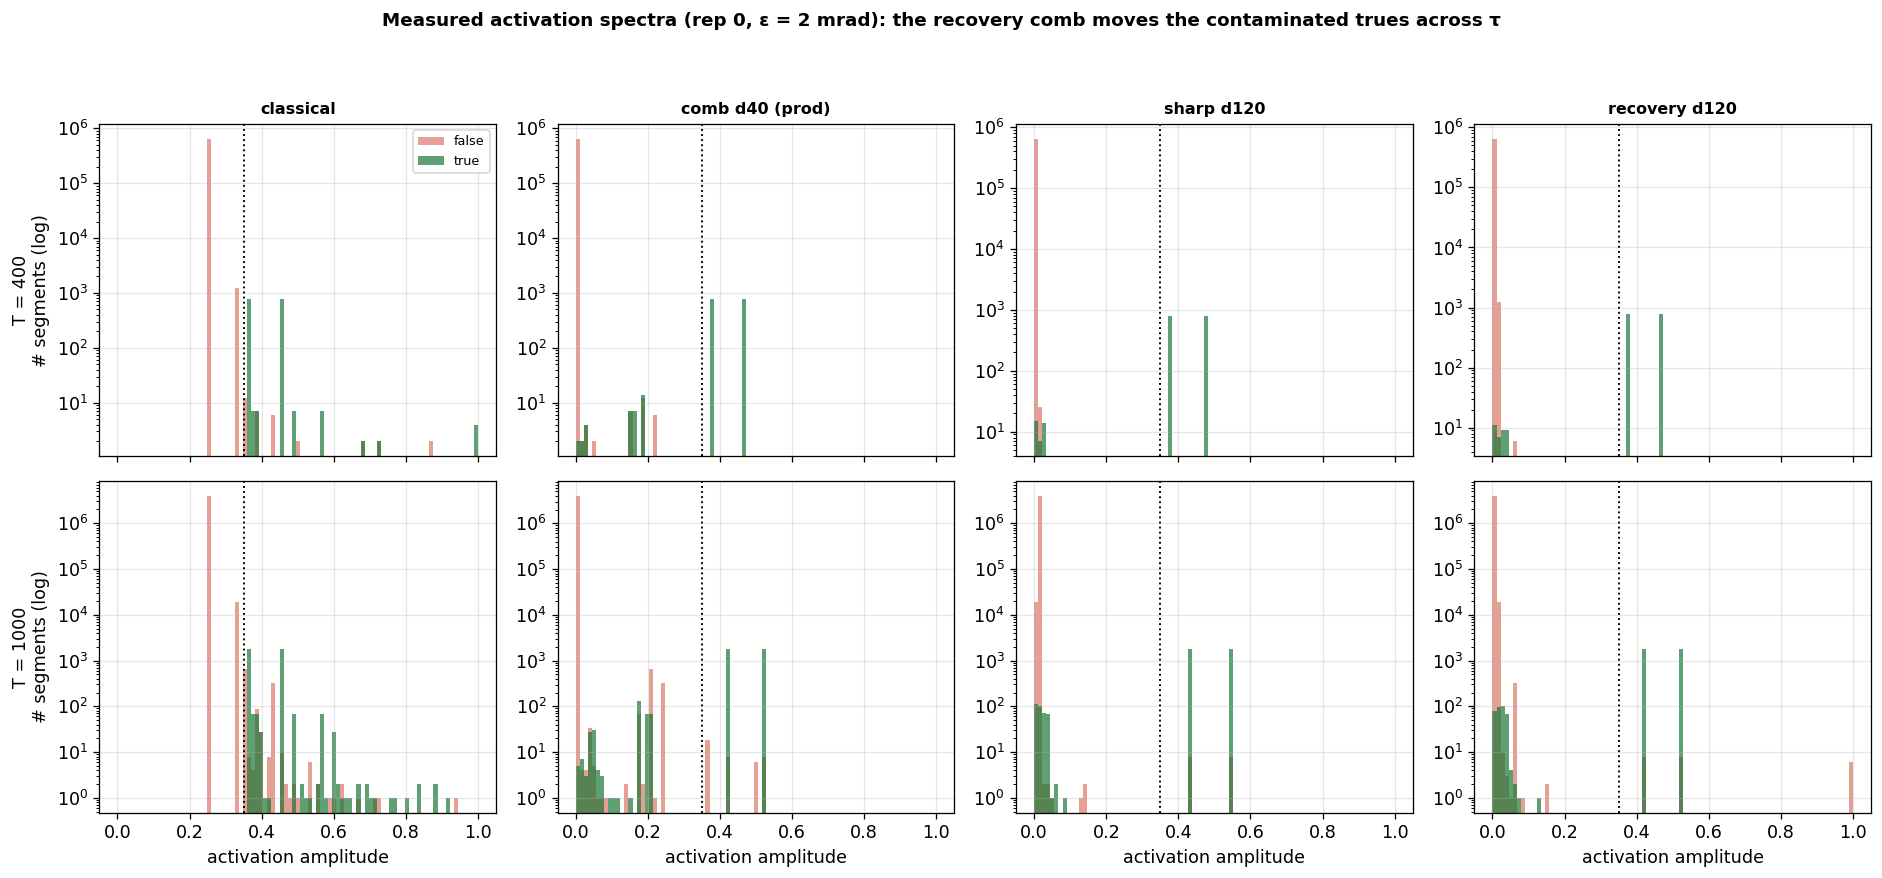

In [9]:
DLIST=["classical","comb d40 (prod)","sharp d120","recovery d120"]
fig,ax=plt.subplots(2,4,figsize=(16.5,7.6),sharex=True)
bins=np.linspace(0,1.0,90)
for i,T in enumerate((400,1000)):
    for j,dsg in enumerate(DLIST):
        a=ax[i,j]; g=get(T,0,dsg)
        if g is None: a.axis("off"); continue
        s,t=g; s=np.clip(s,0,1)
        a.hist(s[~t],bins=bins,color="#d6604d",alpha=0.6,log=True,label="false")
        a.hist(s[t],bins=bins,color="#1b7837",alpha=0.7,log=True,label="true")
        a.axvline(TAU,color="k",ls=":",lw=1.2)
        if i==0: a.set_title(dsg,fontweight="bold",fontsize=10)
        if j==0: a.set_ylabel(f"T = {T}\n# segments (log)")
        if i==1: a.set_xlabel("activation amplitude")
        if i==0 and j==0: a.legend(fontsize=8)
fig.suptitle("Measured activation spectra (rep 0, ε = 2 mrad): the recovery comb moves the contaminated trues across τ",
             fontsize=11.5,fontweight="bold",y=1.0)
fig.tight_layout(rect=[0,0,1,0.96]); savefig(fig,"06_measured_spectra"); plt.show()

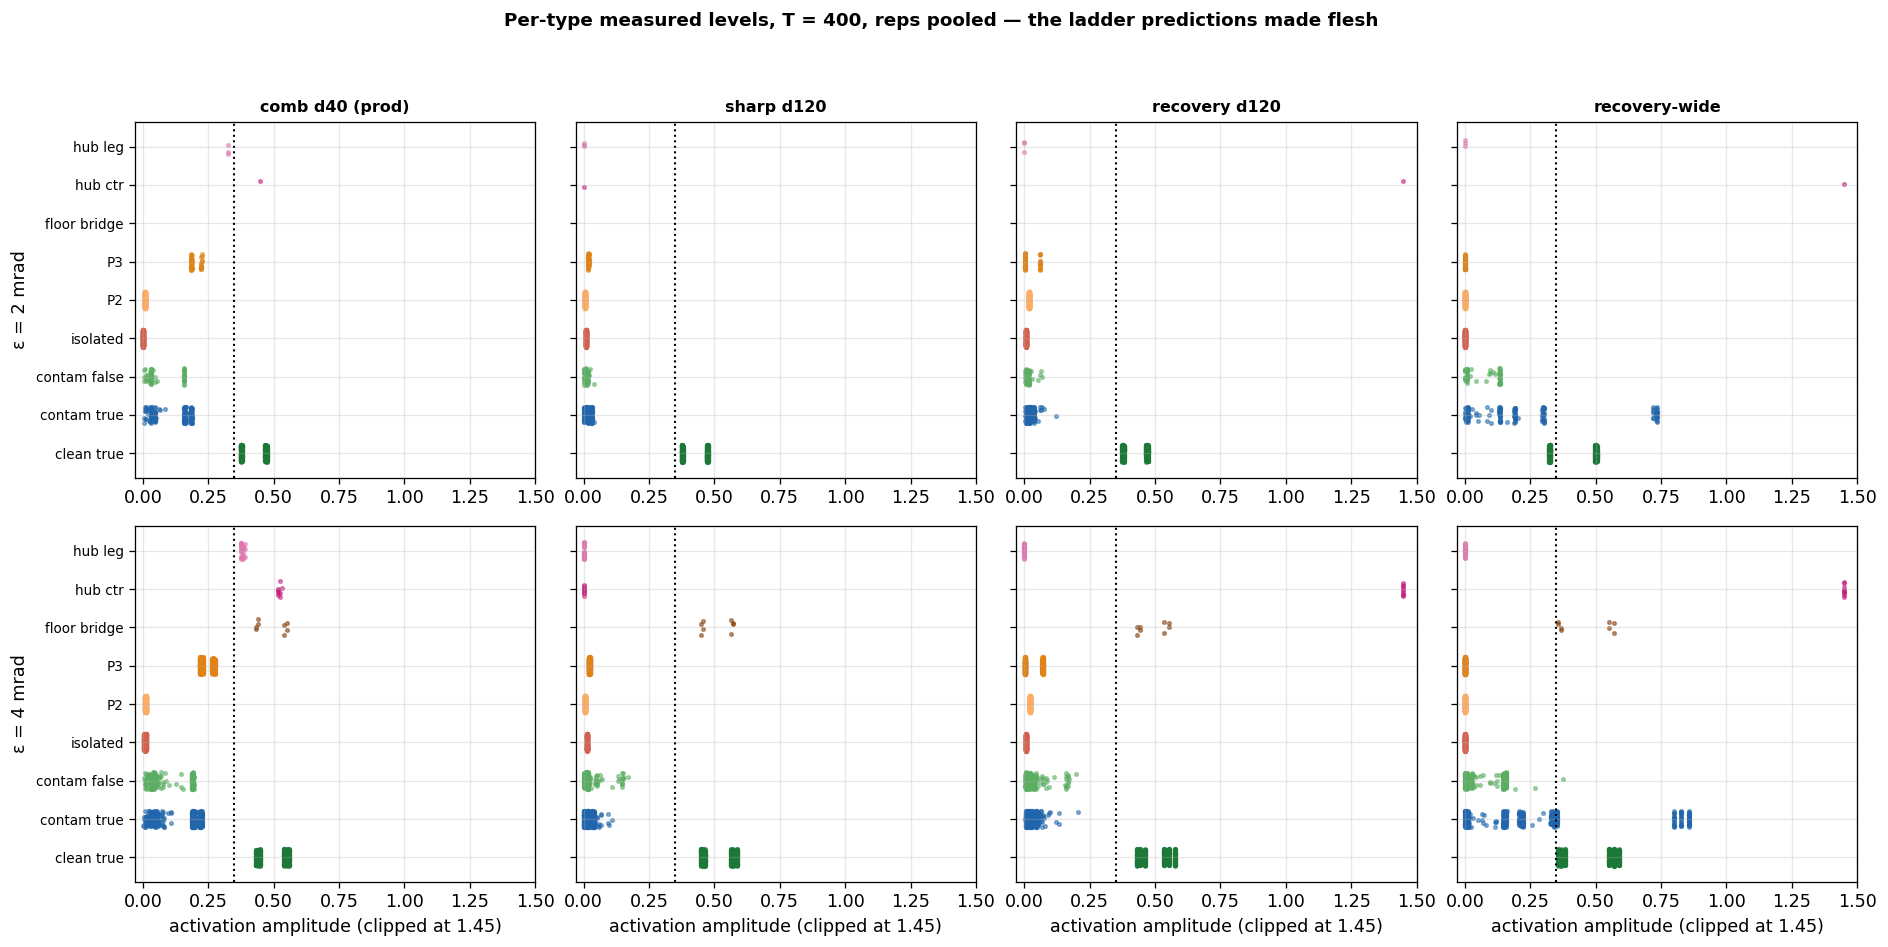

In [10]:
# per-type levels at T=400: 2 mrad and the 4 mrad stress point
SHOW=[("clean true",0,"#1b7837"),("contam true",1,"#2166ac"),("contam false",2,"#5aae61"),
      ("isolated",3,"#d6604d"),("P2",4,"#fdae61"),("P3",5,"#e08214"),
      ("floor bridge",6,"#7f3b08"),("hub ctr",7,"#c51b7d"),("hub leg",8,"#de77ae")]
QD=["comb d40 (prod)","sharp d120","recovery d120","recovery-wide"]
fig,ax=plt.subplots(2,4,figsize=(16.5,8.2),sharey=True)
rng=np.random.default_rng(1)
for i,eps in enumerate((0.002,0.004)):
    for j,dsg in enumerate(QD):
        a=ax[i,j]; SS=[]; TT=[]
        for rep in (0,1,2):
            g=get(400,rep,dsg,eps)
            if g is None: continue
            s,t=g; lab,_,_=census(400,rep,eps)
            SS.append(s); TT.append(lab)
        if not SS: a.axis("off"); continue
        s=np.concatenate(SS); lab=np.concatenate(TT)
        for k,(nm,code_,c) in enumerate(SHOW):
            v=np.clip(s[lab==code_],0,1.45)
            if not len(v): continue
            sub=v if len(v)<=400 else rng.choice(v,400,replace=False)
            a.scatter(sub+0.0*k,np.full(len(sub),k)+rng.uniform(-0.22,0.22,len(sub)),
                      s=5,color=c,alpha=0.5)
        a.axvline(TAU,color="k",ls=":",lw=1.3)
        if i==0: a.set_title(dsg,fontweight="bold",fontsize=10)
        if j==0:
            a.set_yticks(range(len(SHOW))); a.set_yticklabels([x[0] for x in SHOW],fontsize=8.5)
            a.set_ylabel(f"ε = {eps*1e3:.0f} mrad")
        if i==1: a.set_xlabel("activation amplitude (clipped at 1.45)")
        a.set_xlim(-0.03,1.5)
fig.suptitle("Per-type measured levels, T = 400, reps pooled — the ladder predictions made flesh",
             fontsize=11.5,fontweight="bold",y=1.0)
fig.tight_layout(rect=[0,0,1,0.965]); savefig(fig,"07_per_type_levels"); plt.show()

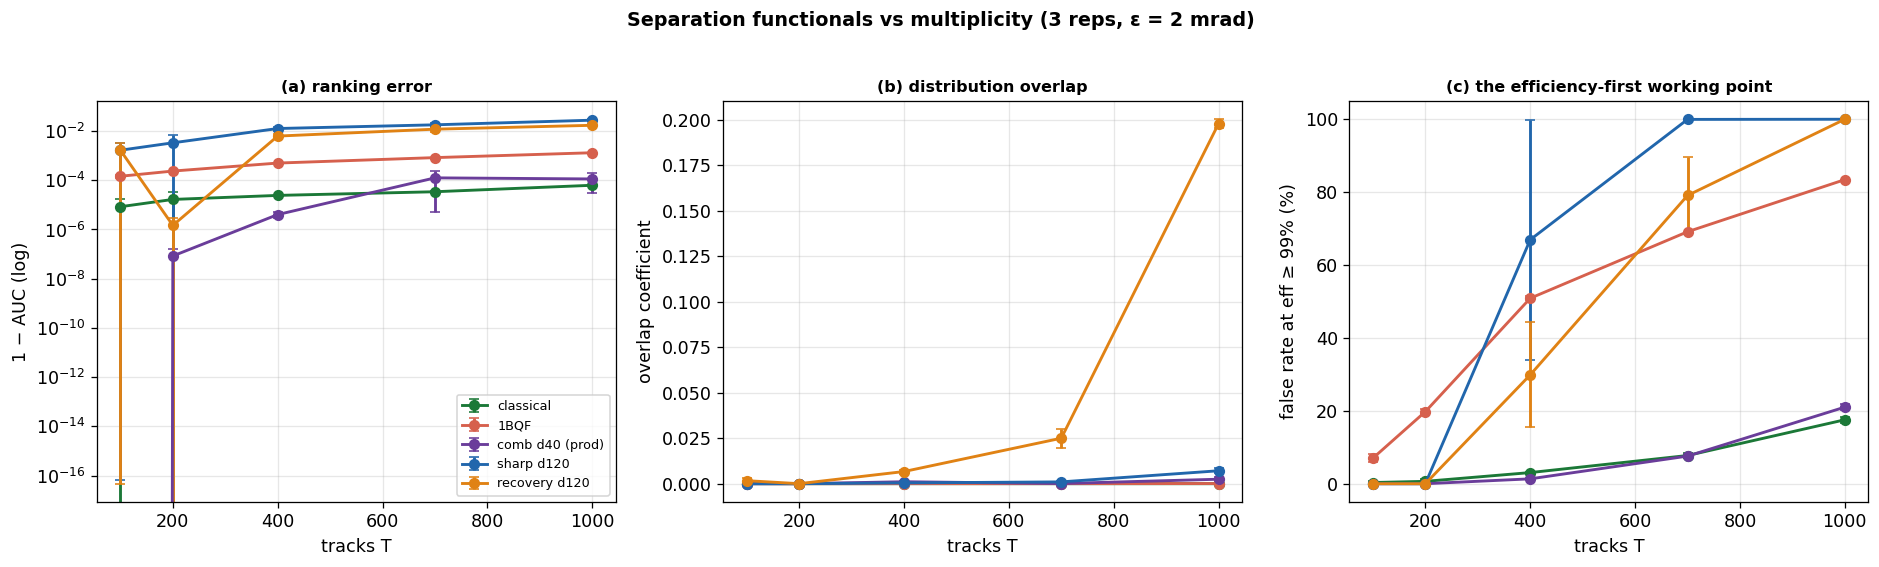

                         AUC  far_eff99
design          T                      
1BQF            100   0.9999     0.0700
                200   0.9998     0.1976
                400   0.9995     0.5084
                700   0.9992     0.6907
                1000  0.9987     0.8335
classical       100   1.0000     0.0032
                200   1.0000     0.0065
                400   1.0000     0.0305
                700   1.0000     0.0773
                1000  0.9999     0.1753
comb d40 (prod) 100   1.0000     0.0000
                200   1.0000     0.0000
                400   1.0000     0.0133
                700   0.9999     0.0757
                1000  0.9999     0.2100
recovery d120   100   0.9983     0.0000
                200   1.0000     0.0000
                400   0.9937     0.2984
                700   0.9881     0.7902
                1000  0.9828     0.9990
sharp d120      100   0.9983     0.0000
                200   0.9967     0.0000
                400   0.9873     0.6688


In [11]:
def auc(s,t):
    pos,neg=s[t],s[~t]
    if not len(pos) or not len(neg): return np.nan
    allv=np.concatenate([pos,neg]); o=allv.argsort(); r=np.empty(len(allv)); r[o]=np.arange(len(allv))
    return float((r[:len(pos)].sum()-len(pos)*(len(pos)-1)/2)/(len(pos)*len(neg)))
def ovl(s,t,nb=300):
    hi=max(1e-9,np.percentile(s,99.9))
    hT,_=np.histogram(s[t],bins=nb,range=(0,hi),density=True)
    hF,e=np.histogram(s[~t],bins=nb,range=(0,hi),density=True)
    return float(np.sum(np.minimum(hT,hF))*(e[1]-e[0]))
def far_at_eff(s,t,e=0.99):
    tau=np.quantile(s[t],1-e)
    act=s>tau
    return float((act&~t).sum()/max(act.sum(),1)),float(tau)
def tau_youden(s,t):
    taus=np.quantile(s,np.linspace(0.5,0.99999,400))
    J=[( (s[t]>x).mean()-(s[~t]>x).mean()) for x in taus]
    return float(taus[int(np.argmax(J))])
DL5=["classical","1BQF","comb d40 (prod)","sharp d120","recovery d120"]
rows=[]
for T in TS:
    for rep in (0,1,2):
        for dsg in DL5:
            g=get(T,rep,dsg)
            if g is None: continue
            s,t=g
            f99,tau99=far_at_eff(s,t,0.99)
            ty=tau_youden(s,t)
            rows.append(dict(T=T,rep=rep,design=dsg,AUC=auc(s,t),OVL=ovl(s,t),
                far_eff99=f99,tau_wp99=tau99,
                eff_fix=float((s[t]>TAU).mean()),far_fix=float(((s>TAU)&~t).sum()/max((s>TAU).sum(),1)),
                eff_y=float((s[t]>ty).mean()),far_y=float(((s>ty)&~t).sum()/max((s>ty).sum(),1))))
SEP=pd.DataFrame(rows)
GS=SEP.groupby(["design","T"]).agg(["mean","sem"])
fig,ax=plt.subplots(1,3,figsize=(16.5,4.8))
for dsg in DL5:
    d=SEP[SEP.design==dsg].groupby("T").mean(numeric_only=True)
    e=SEP[SEP.design==dsg].groupby("T").sem(numeric_only=True)
    ax[0].errorbar(d.index,1-d.AUC,yerr=e.AUC,fmt="o-",color=DCOL[dsg],lw=1.8,capsize=3,label=dsg)
    ax[1].errorbar(d.index,d.OVL,yerr=e.OVL,fmt="o-",color=DCOL[dsg],lw=1.8,capsize=3)
    ax[2].errorbar(d.index,100*d.far_eff99,yerr=100*e.far_eff99,fmt="o-",color=DCOL[dsg],lw=1.8,capsize=3)
ax[0].set_yscale("log"); ax[0].set_ylabel("1 − AUC (log)"); ax[0].set_title("(a) ranking error",fontweight="bold",fontsize=10)
ax[1].set_ylabel("overlap coefficient"); ax[1].set_title("(b) distribution overlap",fontweight="bold",fontsize=10)
ax[2].set_ylabel("false rate at eff ≥ 99% (%)"); ax[2].set_title("(c) the efficiency-first working point",fontweight="bold",fontsize=10)
for a in ax: a.set_xlabel("tracks T")
ax[0].legend(fontsize=8)
fig.suptitle("Separation functionals vs multiplicity (3 reps, ε = 2 mrad)",fontsize=12,fontweight="bold",y=1.02)
fig.tight_layout(); savefig(fig,"08_separation_vs_T"); plt.show()
print(SEP.groupby(["design","T"])[["AUC","far_eff99"]].mean().round(4).to_string())

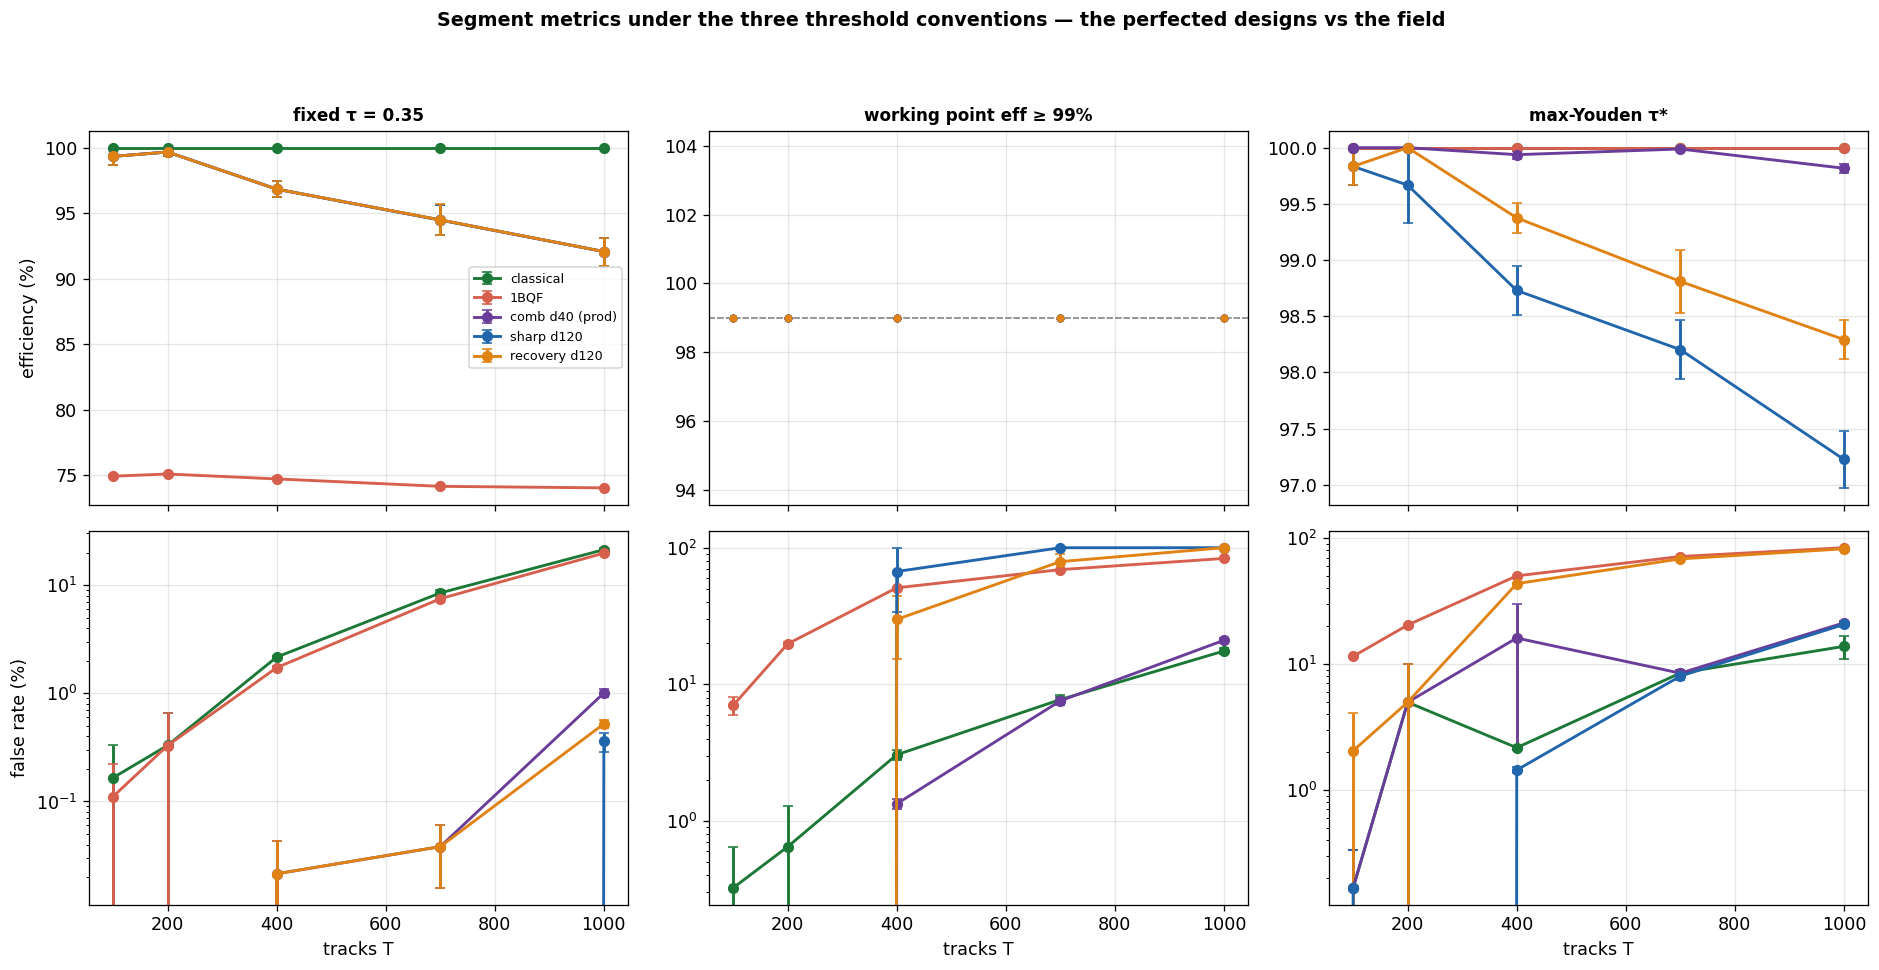

LCU success probability (statevector, T=400 rep0, ε=2mrad):
       sharp d120: P_anc = 1.381e-03
    recovery d120: P_anc = 2.993e-05
    recovery-wide: P_anc = 2.530e-05

T=1000 summary (mean over reps):
                    AUC  eff_fix  far_fix  far_eff99   eff_y   far_y
design                                                              
1BQF             0.9987   0.7402   0.1976     0.8335  1.0000  0.8407
classical        0.9999   1.0000   0.2127     0.1753  1.0000  0.1382
comb d40 (prod)  0.9999   0.9207   0.0101     0.2100  0.9982  0.2123
recovery d120    0.9828   0.9207   0.0052     0.9990  0.9829  0.8241
sharp d120       0.9723   0.9207   0.0036     0.9990  0.9722  0.2063


In [12]:
fig,ax=plt.subplots(2,3,figsize=(16.5,8.4),sharex=True)
CONV=[("fixed τ = 0.35","eff_fix","far_fix"),
      ("working point eff ≥ 99%",None,"far_eff99"),
      ("max-Youden τ*","eff_y","far_y")]
for j,(name,ek,fk) in enumerate(CONV):
    for dsg in DL5:
        d=SEP[SEP.design==dsg].groupby("T").mean(numeric_only=True)
        e=SEP[SEP.design==dsg].groupby("T").sem(numeric_only=True)
        if ek is None:
            ax[0,j].axhline(99.0,color="0.6",ls="--",lw=1)
            ax[0,j].plot(d.index,[99]*len(d.index),"o",color=DCOL[dsg],ms=4)
        else:
            ax[0,j].errorbar(d.index,100*d[ek],yerr=100*e[ek],fmt="o-",color=DCOL[dsg],lw=1.8,capsize=3,label=dsg)
        ax[1,j].errorbar(d.index,100*d[fk],yerr=100*e[fk],fmt="o-",color=DCOL[dsg],lw=1.8,capsize=3)
    ax[0,j].set_title(name,fontweight="bold",fontsize=10.5)
    ax[1,j].set_xlabel("tracks T")
ax[0,0].set_ylabel("efficiency (%)"); ax[1,0].set_ylabel("false rate (%)")
ax[0,0].legend(fontsize=8); ax[1,0].set_yscale("log"); ax[1,1].set_yscale("log"); ax[1,2].set_yscale("log")
fig.suptitle("Segment metrics under the three threshold conventions — the perfected designs vs the field",
             fontsize=12,fontweight="bold",y=1.0)
fig.tight_layout(rect=[0,0,1,0.96]); savefig(fig,"09_conventions_metrics"); plt.show()
# success probabilities of the fresh designs
print("LCU success probability (statevector, T=400 rep0, ε=2mrad):")
for dsg in ("sharp d120","recovery d120","recovery-wide"):
    _,succ=fresh(400,0,0.002,dsg)
    print(f"  {dsg:>15}: P_anc = {succ:.3e}")
r=SEP[(SEP["T"]==1000)].groupby("design").mean(numeric_only=True)
print("\nT=1000 summary (mean over reps):")
print(r[["AUC","eff_fix","far_fix","far_eff99","eff_y","far_y"]].round(4).to_string())

### 5b. What the measurement teaches: broadband beats line surgery — so optimise the family

The conventions plot shows the surprise: at the efficiency-first working point the
*production* comb beats both perfected designs once contamination matters. The
mechanism is in the ladder itself — the d = 40, hw = 0.18 comb's wide Gaussian tails
give contaminated trues 0.23–0.46 (**accidental broadband recovery**, graded by the
distance of each cluster's lines from the P4 lines), while the narrow targeted passes
recover only the exact-P5 minority (46 % of contaminated lines are in the passes) and
the mirror tax pins recovered falses at exactly the recovered-true level. Real
contamination is spectrally heterogeneous; a fixed line comb cannot chase it.

The honest perfecting move is therefore a **measured (d, hw) optimisation of the comb
family** on the working-point objective, on the same store events (cached scan):

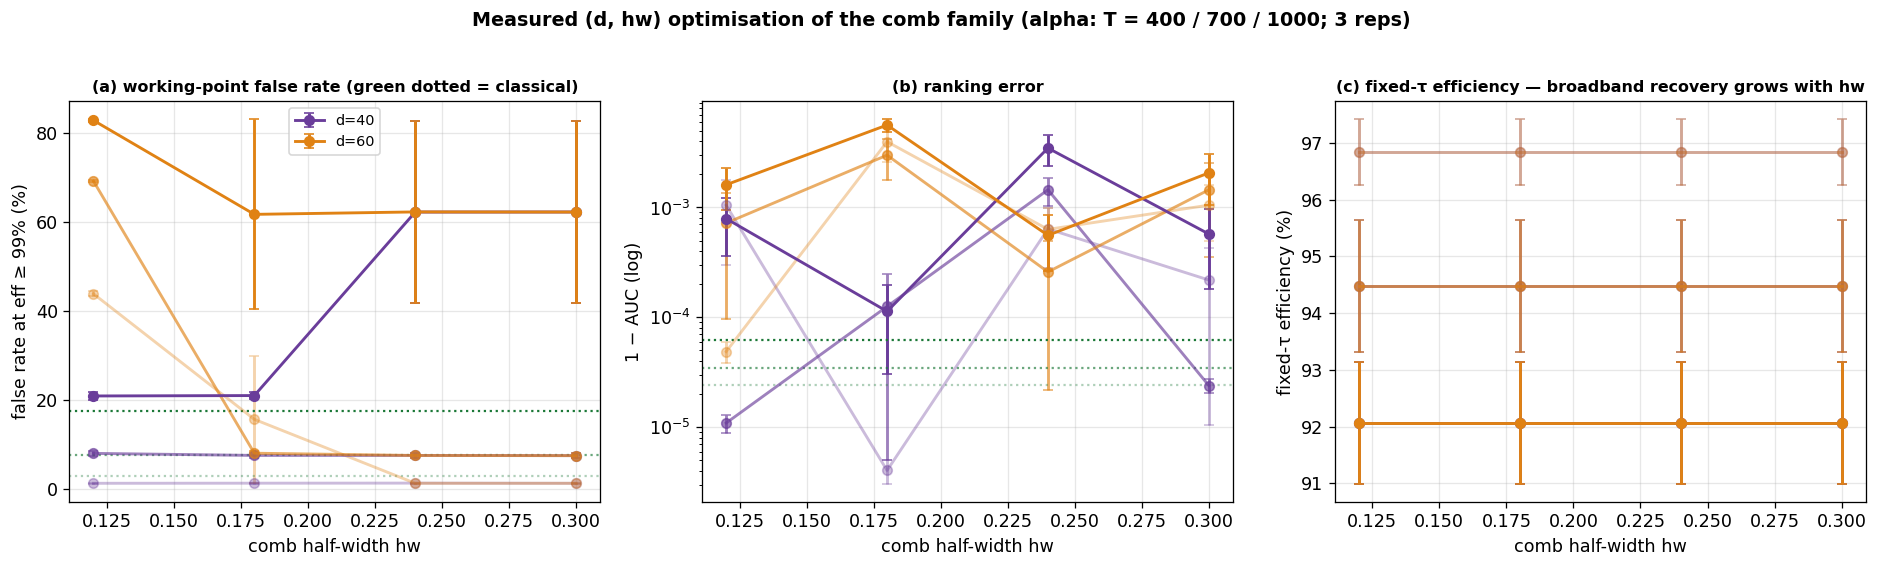

   T  d   hw  rep    AUC  eff_fix  far_fix  far_eff99
1000 40 0.12  1.0 0.9992   0.9207   0.0101     0.2092
1000 40 0.18  1.0 0.9999   0.9207   0.0101     0.2101
1000 40 0.24  1.0 0.9965   0.9207   0.0101     0.6223
1000 40 0.30  1.0 0.9994   0.9207   0.0101     0.6225
1000 60 0.12  1.0 0.9984   0.9207   0.0052     0.8282
1000 60 0.18  1.0 0.9944   0.9207   0.0052     0.6172
1000 60 0.24  1.0 0.9994   0.9207   0.0074     0.6226
1000 60 0.30  1.0 0.9979   0.9207   0.0101     0.6223


In [13]:
DH=pd.read_csv(CACHE/"dhw_measured_scan.csv")
GD=DH.groupby(["T","d","hw"]).mean(numeric_only=True).reset_index()
GE=DH.groupby(["T","d","hw"]).sem(numeric_only=True).reset_index()
fig,ax=plt.subplots(1,3,figsize=(16.5,4.8))
for T,al in ((400,0.35),(700,0.65),(1000,1.0)):
    for d,c in ((40,"#6a3d9a"),(60,"#e08214")):
        g=GD[(GD["T"]==T)&(GD.d==d)].sort_values("hw")
        e=GE[(GE["T"]==T)&(GE.d==d)].sort_values("hw")
        lab=f"d={d}" if T==1000 else None
        ax[0].errorbar(g.hw,100*g.far_eff99,yerr=100*e.far_eff99,fmt="o-",color=c,alpha=al,lw=1.8,capsize=3,label=lab)
        ax[1].errorbar(g.hw,1-g.AUC,yerr=e.AUC,fmt="o-",color=c,alpha=al,lw=1.8,capsize=3)
        ax[2].errorbar(g.hw,100*g.eff_fix,yerr=100*e.eff_fix,fmt="o-",color=c,alpha=al,lw=1.8,capsize=3)
cl=SEP[SEP.design=="classical"].groupby("T").mean(numeric_only=True)
for T,al in ((400,0.35),(700,0.65),(1000,1.0)):
    ax[0].axhline(100*cl.loc[T,"far_eff99"],color="#1b7837",ls=":",lw=1.4,alpha=al)
    ax[1].axhline(1-cl.loc[T,"AUC"],color="#1b7837",ls=":",lw=1.4,alpha=al)
ax[0].set_ylabel("false rate at eff ≥ 99% (%)"); ax[0].set_title("(a) working-point false rate (green dotted = classical)",fontweight="bold",fontsize=10)
ax[1].set_yscale("log"); ax[1].set_ylabel("1 − AUC (log)"); ax[1].set_title("(b) ranking error",fontweight="bold",fontsize=10)
ax[2].set_ylabel("fixed-τ efficiency (%)"); ax[2].set_title("(c) fixed-τ efficiency — broadband recovery grows with hw",fontweight="bold",fontsize=10)
for a in ax: a.set_xlabel("comb half-width hw")
ax[0].legend(fontsize=9)
fig.suptitle("Measured (d, hw) optimisation of the comb family (alpha: T = 400 / 700 / 1000; 3 reps)",
             fontsize=12,fontweight="bold",y=1.02)
fig.tight_layout(); savefig(fig,"10_dhw_measured_scan"); plt.show()
print(GD[GD["T"]==1000].round(4).to_string(index=False))

## 6. Verdict — what "perfect" means on the toy

**The two imperfections of the production comb are one spectral object.** The
contaminated-P5 odd lines and the hub-$K_{1,3}$ lines coincide exactly at $s\pm\sqrt3$
(§1), so contaminated-true recovery and hub rejection are coupled by *theorem*, not by
design accident: any spectral filter that recovers contaminated trues to level $x$
admits a hub population at $\ge \tfrac32 x$ (§2), and within-cluster mirror symmetry
pins one recovered false per recovered cluster at **exactly** the recovered-true level
(the mirror tax). The canonical optimum — leg-null, concentrating the unavoidable hub
survival in the single centre segment — exists and was built (§3): on the ladder it is
flawless (P5-outer = P4-outer = 0.364, hub-leg = 0.0000, every other false ≤ 0.06), at
a ×0.11 success-probability price. Widening its passes is inadmissible (hwr = 0.12 →
success ×0.003 and the P4-outer level distorted to 0.295): the recovery window is boxed
in by the P6 line 0.07 below and the P4-outer line 0.114 above.

**The measurement vetoes line surgery.** Real contamination is spectrally
heterogeneous — only 46 % of contaminated-cluster excited lines fall inside the
$s\pm\sqrt3$ passes (§4c), and only 0.3 % near the P4 lines — while the production
comb's wide tails (hw = 0.18) already perform *graded broadband recovery*
(P5 levels 0.23–0.46, falling with line distance). On the store events (§5):

- **fixed τ = 0.35**: every comb's efficiency equals the clean fraction (96.8 / 94.5 /
  92.1 % at T = 400/700/1000) — no comb recovers real contamination at this threshold,
  while the classical flat $1/\lambda$ recovers all of it (eff = 100 %). The combs
  differ only in purity: sharp 0.36 % < recovery 0.52 % < production 1.0 % false rate
  at T = 1000.
- **the efficiency-first working point (eff ≥ 99 %)**: the *production* comb wins among
  QSVT designs at every T (1.3 / 7.6 / 21 % vs classical 3.1 / 7.7 / 17.5 %): better
  than classical to T ≈ 700, slightly behind at T = 1000. The targeted designs
  degenerate here (partial recovery + mirror tax put the 1 % true quantile inside the
  grass).
- **ranking (AUC)**: classical and production comb are tied at 0.9999; sharp/recovery
  pay 0.97–0.98 for dropping/partially-lifting the contaminated 8 %.

**The family is closed.** The measured (d, hw) scan (§5b) puts d = 40,
hw = 0.12–0.18 on a plateau optimum at every multiplicity — nothing in the family beats
the production point on the working-point objective; the minimax (LP) comb is
inadequate on the ladder at every degree (hub 0.4–0.6, isolated ≤ 0.2 only for
d ≥ 16). Together with the theorem (§2), the heterogeneity census (§4) and the scan,
the comb-design question on the toy is **solved**:

| design | role | T = 1000, fixed τ | T = 1000, eff ≥ 99 % |
|---|---|---|---|
| **comb d40 hw0.18** | *the* production QSVT design | eff 92.1 %, far 1.0 % | far 21 % |
| **sharp d120 hw0.06** | high-purity variant (×3 cleaner) | eff 92.1 %, far 0.36 % | degenerate |
| **recovery d120** | the theorem made constructive — paper exhibit | eff 92.1 %, far 0.52 % | degenerate |
| classical 1/λ | broadband reference | eff 100 %, far 21 % | far 17.5 % |

Success probabilities (T = 400 statevector): sharp 1.4 × 10⁻³ (production scale),
recovery 3.0 × 10⁻⁵ (the renormalisation + narrow-pass cost).

**What remains is not design.** Fixed-τ efficiency at density is bought only by
accepting false structure wholesale (classical), and the working-point gap beyond
T ≈ 700 is the mirror tax plus composition — which the floor-theorem family proves no
spectral filter can beat. The toy's QSVT design story is complete; the open frontier is
the Run-3 geometry (variable track length, line-union spectra), where this same
framework already runs (notebooks `QSVT/Run3/01-02`). If a high-purity working point is
ever wanted in production, promoting the sharp comb is a one-line addition to
`qp.solve_qsvt` (`filter_design="sharp"`).